In [2]:
import pandas as pd

df = pd.read_csv("cleaned_churn_data.csv")  # use your file name

In [3]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup'],
      dtype='object')


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
TenureGroup         11
dtype: int64

In [6]:
# Fix column names
df.columns = df.columns.str.strip()

# Convert TotalCharges safely
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
    df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID if exists
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

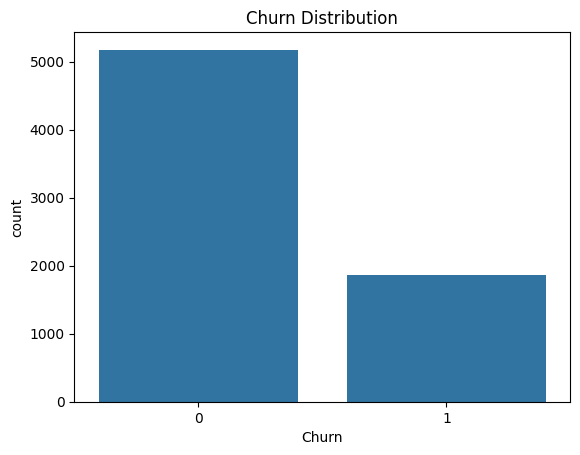

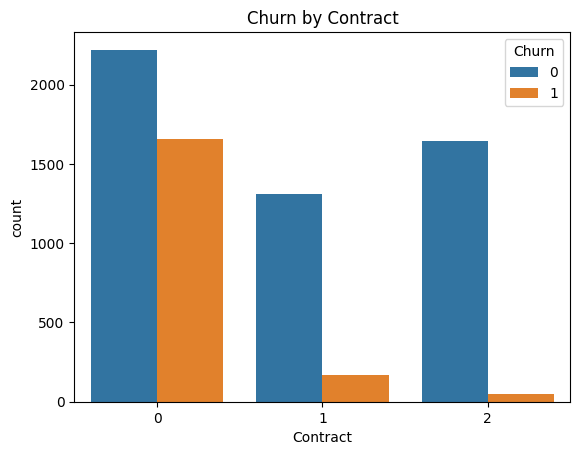

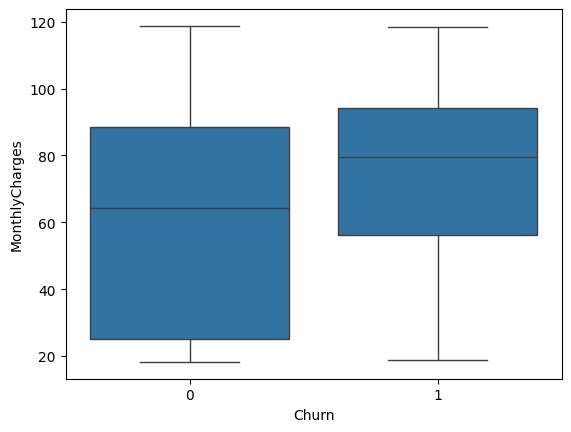

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Contract vs Churn
if "Contract" in df.columns:
    sns.countplot(x='Contract', hue='Churn', data=df)
    plt.title("Churn by Contract")
    plt.show()

# Monthly Charges vs Churn
if "MonthlyCharges" in df.columns:
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
    plt.show()

In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, y_pred)
print("Logistic Regression:", lr_acc)

Logistic Regression: 0.8168914123491838


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
print("Decision Tree:", dt_acc)

Decision Tree: 0.7366926898509581


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))
print("Random Forest:", rf_acc)

Random Forest: 0.7955997161107168


In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, dt_acc, rf_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.816891
1        Decision Tree  0.736693
2        Random Forest  0.795600


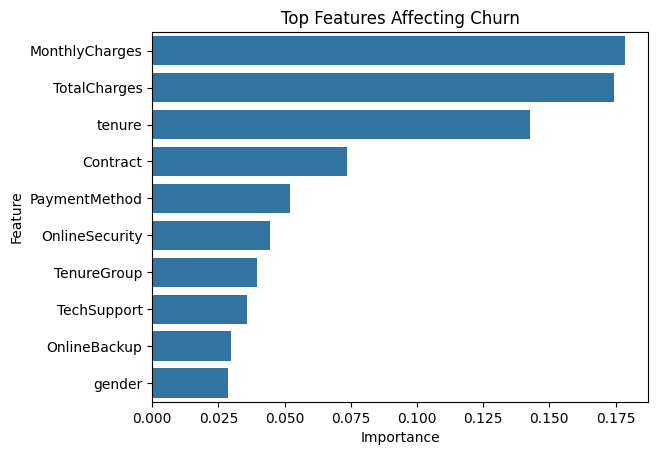

In [17]:
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

import seaborn as sns
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top Features Affecting Churn")
plt.show()

In [18]:
df.to_csv("cleaned_churn_data.csv", index=False)

In [19]:
print("Insights:")
print("- Customers with high monthly charges tend to churn")
print("- Short tenure customers churn more")
print("- Month-to-month contracts have high churn")
print("- Long-term customers are more loyal")

Insights:
- Customers with high monthly charges tend to churn
- Short tenure customers churn more
- Month-to-month contracts have high churn
- Long-term customers are more loyal
